In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

In [ ]:
# Ищем вероятность токена среди логитов
def get_token_prob_case_insensitive(logits, target):
    for step in logits:
        total = 0
        for token, prob in step:
            if token.lower() == target:
                total += float(prob)
        if total > 0:
            return total
    return None

## Text
Изображение и описание не совпадают, вопрос задаём по тексту.

In [ ]:
t_data = pd.read_csv("text_results.csv")

In [ ]:
t_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs
0,text,882048099.jpg,A woman in a blue bathing suit and straw hat ...,Four women in all black barefoot posing on th...,Four women in all black barefoot posing on th...,5922945248.jpg,Are there women posing on the beach?,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
1,text,199413509.jpg,A woman peers out from her halfway opened blu...,A man in a blue shirt smiles at a baby he 's ...,A man in a blue shirt smiles at a baby he 's ...,787907341.jpg,Is there a man smiling at a baby in a sling?,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
2,text,2825540754.jpg,a little boy is running on the beach with a r...,A young man dressed in black dress clothes li...,A young man dressed in black dress clothes li...,3823691082.jpg,Is a young man lying down with his head in the...,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
3,text,4850944716.jpg,an older man wearing a suit has his arms fold...,The little girl wearing a pink hat is bending...,The little girl wearing a pink hat is bending...,537579448.jpg,Is there a little girl wearing a pink hat?,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."
4,text,4526883901.jpg,"A white-haired man with glasses , wearing a g...",A woman in a brown UPS uniform is handling pa...,A woman in a brown UPS uniform is handling pa...,3384702365.jpg,Is there a woman in a brown UPS uniform handli...,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[('[', '1.000000'), ('#', '0.000000'), ('!', ..."


In [ ]:
t_data["model_answer"] = None
t_data["verb_confidence"] = None
for i in t_data.index:
  output = t_data.at[i, "model_output"][1:-1].split(", ")
  try:
    t_data.at[i, "model_answer"] = output[0].lower()
    t_data.at[i, "verb_confidence"] = output[1].lower()
  except:
    t_data.at[i, "model_answer"] = "Invalid output"
    t_data.at[i, "verb_confidence"] = "Invalid output"

In [ ]:
t_data["model_answer"].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
t_data["verb_confidence"].unique()

array(['95', '0', '75', '70', '100', '90', '50', '80'], dtype=object)

In [ ]:
text_bias = (t_data["model_answer"] == "yes").mean()
text_bias

np.float64(0.07666666666666666)

In [ ]:
image_bias = (t_data["model_answer"] == "no").mean()
image_bias

np.float64(0.9233333333333333)

In [ ]:
t_data["output_probs"] = t_data["output_probs"].apply(ast.literal_eval)

In [ ]:
t_data["model_answer"][1], t_data["output_probs"][1]

('no',
 [[('[', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('NO', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(',', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(' ', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('0', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(']', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('<|im_end|>', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')]])

In [ ]:
t_data["int_confidence"] = None
for i in t_data.index:
  t_data.at[i, "int_confidence"] = get_token_prob_case_insensitive(t_data["output_probs"][i], t_data["model_answer"][i])


In [ ]:
t_data["int_confidence"] = t_data["int_confidence"] * 100

In [ ]:
t_data["verb_confidence"] = pd.to_numeric(
    t_data["verb_confidence"],
    errors="coerce"
)

In [ ]:
t_data[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.00000,-0.22344
int_confidence,-0.22344,1.00000


In [ ]:
t_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence
0,text,882048099.jpg,A woman in a blue bathing suit and straw hat ...,Four women in all black barefoot posing on th...,Four women in all black barefoot posing on th...,5922945248.jpg,Are there women posing on the beach?,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0
1,text,199413509.jpg,A woman peers out from her halfway opened blu...,A man in a blue shirt smiles at a baby he 's ...,A man in a blue shirt smiles at a baby he 's ...,787907341.jpg,Is there a man smiling at a baby in a sling?,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,0,100.0
2,text,2825540754.jpg,a little boy is running on the beach with a r...,A young man dressed in black dress clothes li...,A young man dressed in black dress clothes li...,3823691082.jpg,Is a young man lying down with his head in the...,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,0,100.0
3,text,4850944716.jpg,an older man wearing a suit has his arms fold...,The little girl wearing a pink hat is bending...,The little girl wearing a pink hat is bending...,537579448.jpg,Is there a little girl wearing a pink hat?,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,0,100.0
4,text,4526883901.jpg,"A white-haired man with glasses , wearing a g...",A woman in a brown UPS uniform is handling pa...,A woman in a brown UPS uniform is handling pa...,3384702365.jpg,Is there a woman in a brown UPS uniform handli...,You need to formulate a single binary (yes/no)...,"[NO, 0]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,0,100.0


In [ ]:
t_data["int_confidence"].unique()

array([100.0, 50.0, 74.4869, 67.1348, 74.4868, 32.8653, 80.6678,
       67.13470000000001, 58.834900000000005], dtype=object)

In [ ]:
t_data["verb_confidence"].unique()

array([ 95,   0,  75,  70, 100,  90,  50,  80])

In [ ]:
text_mask = (t_data["model_answer"] == "yes")
text_result = t_data[text_mask]
image_mask = (t_data["model_answer"] == "no")
image_result = t_data[image_mask]

In [ ]:
text_result["int_confidence"].mean()

np.float64(91.54831304347827)

In [ ]:
text_result["verb_confidence"].mean()

np.float64(93.91304347826087)

In [ ]:
image_result["int_confidence"].mean()

np.float64(98.54883104693143)

In [ ]:
image_result["verb_confidence"].mean()

np.float64(11.80505415162455)

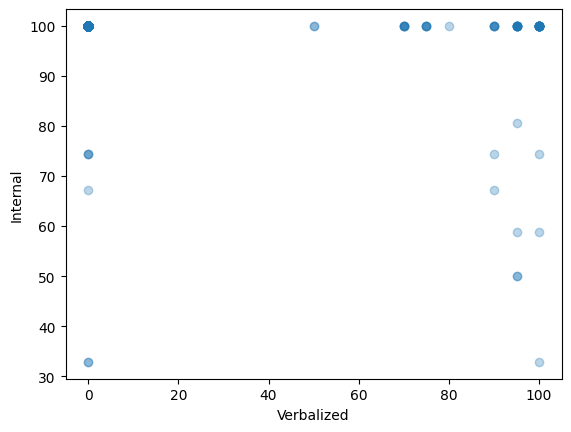

In [ ]:
# Связь между вербализованной и внутренней увереностью

plt.scatter(t_data["verb_confidence"], t_data["int_confidence"], alpha=0.3)
plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

<Axes: ylabel='Frequency'>

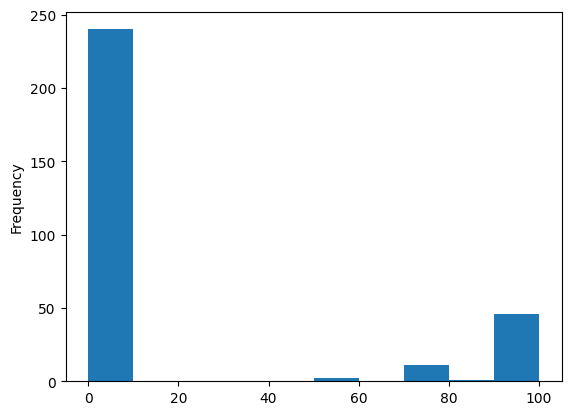

In [ ]:
# Вербализованная уверенность
t_data["verb_confidence"].plot(kind='hist')

<Axes: ylabel='Frequency'>

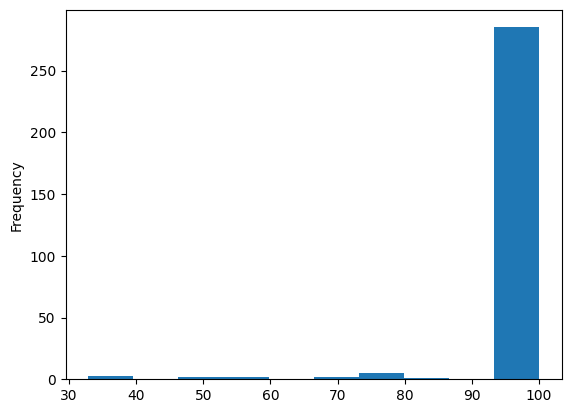

In [ ]:
# Внутрення уверенность
t_data["int_confidence"].plot(kind='hist')

##IMAGE
Изображение и описание отличаются, вопрос задаём по картинке.

In [ ]:
i_data = pd.read_csv("image_results.csv")

In [ ]:
i_data["model_answer"] = None
i_data["verb_confidence"] = None
for i in i_data.index:
  output = i_data.at[i, "model_output"][1:-1].split(", ")
  try:
    i_data.at[i, "model_answer"] = output[0].lower()
    i_data.at[i, "verb_confidence"] = output[1].lower()
  except:
    i_data.at[i, "model_answer"] = "Invalid output"
    i_data.at[i, "verb_confidence"] = "Invalid output"

In [ ]:
i_data["model_answer"].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
i_data["verb_confidence"].unique()

array(['95', '80', '90', '100', '75', '0', '70', '85'], dtype=object)

In [ ]:
t_bias = (i_data["model_answer"] == "yes").mean()
t_bias

np.float64(0.89)

In [ ]:
i_bias = (i_data["model_answer"] == "no").mean()
i_bias

np.float64(0.11)

In [ ]:
i_data["output_probs"] = i_data["output_probs"].apply(ast.literal_eval)

In [ ]:
i_data["model_answer"][1], i_data["output_probs"][1]

('no',
 [[('[', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('NO', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(',', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(' ', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('7', '0.563048'),
   ('8', '0.275635'),
   ('1', '0.161316'),
   ('"', '0.000000'),
   ('!', '0.000000')],
  [('0', '0.671348'),
   ('5', '0.328652'),
   ('#', '0.000000'),
   ('"', '0.000000'),
   ('!', '0.000000')],
  [(']', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('<|im_end|>', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')]])

In [ ]:
i_data["int_confidence"] = None
for i in i_data.index:
  i_data.at[i, "int_confidence"] = get_token_prob_case_insensitive(i_data["output_probs"][i], i_data["model_answer"][i])


In [ ]:
i_data["int_confidence"] = i_data["int_confidence"] * 100

In [ ]:
i_data["verb_confidence"] = pd.to_numeric(
    i_data["verb_confidence"],
    errors="coerce"
)

In [ ]:
i_data[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.000000,0.115965
int_confidence,0.115965,1.000000


In [ ]:
i_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence
0,image,882048099.jpg,A woman in a blue bathing suit and straw hat ...,Four women in all black barefoot posing on th...,A woman in a blue bathing suit and straw hat ...,5922945248.jpg,Is there a woman in a blue bathing suit and st...,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0
1,image,199413509.jpg,A woman peers out from her halfway opened blu...,A man in a blue shirt smiles at a baby he 's ...,A woman peers out from her halfway opened blu...,787907341.jpg,Is there a woman peeking out from a blue door?,You need to formulate a single binary (yes/no)...,"[NO, 80]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,80,100.0
2,image,2825540754.jpg,a little boy is running on the beach with a r...,A young man dressed in black dress clothes li...,a little boy is running on the beach with a r...,3823691082.jpg,Is there a little boy running on the beach wit...,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0
3,image,4850944716.jpg,an older man wearing a suit has his arms fold...,The little girl wearing a pink hat is bending...,an older man wearing a suit has his arms fold...,537579448.jpg,Is there an older man in a suit looking in a s...,You need to formulate a single binary (yes/no)...,"[YES, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,90,100.0
4,image,4526883901.jpg,"A white-haired man with glasses , wearing a g...",A woman in a brown UPS uniform is handling pa...,"A white-haired man with glasses , wearing a g...",3384702365.jpg,Is there a man working on a sculpture?,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0


In [ ]:
i_data["int_confidence"].unique()

array([100.0, 80.6678, 41.165099999999995, 74.4869, 25.5132, 67.1348,
       50.0, 58.834900000000005], dtype=object)

In [ ]:
i_data["verb_confidence"].unique()

array([ 95,  80,  90, 100,  75,   0,  70,  85])

In [ ]:
text_mask = (i_data["model_answer"] == "no")
text_result = i_data[text_mask]
image_mask = (i_data["model_answer"] == "yes")
image_result = i_data[image_mask]

In [ ]:
text_result["int_confidence"].mean()

np.float64(97.97944848484848)

In [ ]:
text_result["verb_confidence"].mean()

np.float64(65.45454545454545)

In [ ]:
image_result["int_confidence"].mean()

np.float64(98.83508539325842)

In [ ]:
image_result["verb_confidence"].mean()

np.float64(92.54681647940075)

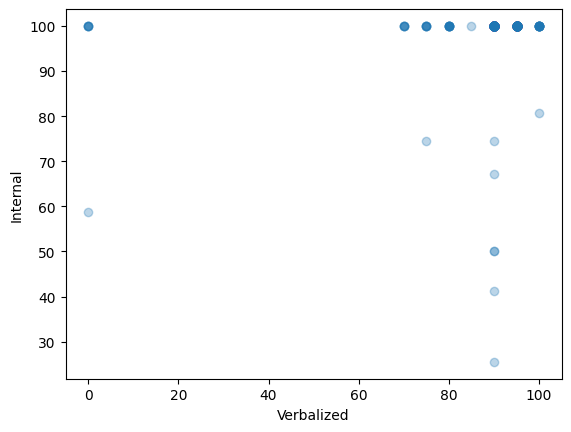

In [ ]:
# Связь между вербализованной и внутренней увереностью

plt.scatter(i_data["verb_confidence"], i_data["int_confidence"], alpha=0.3)
plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

<Axes: ylabel='Frequency'>

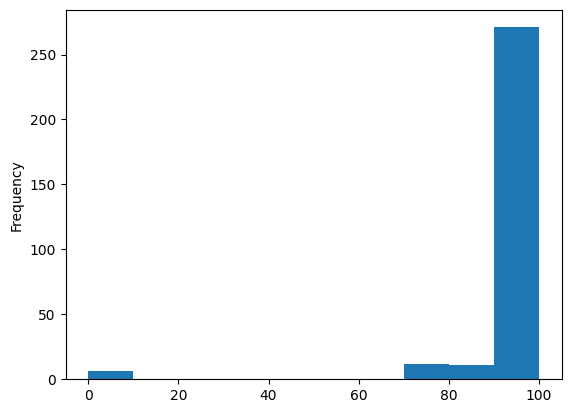

In [ ]:
# Вербализованная уверенность
i_data["verb_confidence"].plot(kind='hist')

<Axes: ylabel='Frequency'>

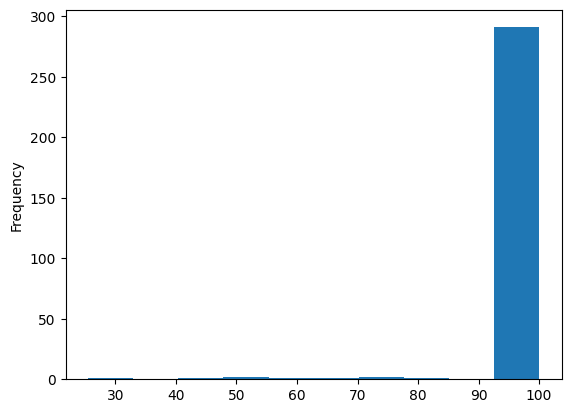

In [ ]:
# Внутренняя уверенность
i_data["int_confidence"].plot(kind='hist')

## Concurrence
Изображение и описание совпадают, вопрос по картинке/ описанию.

In [ ]:
c_data = pd.read_csv("concurrence_results.csv")

In [ ]:
c_data["model_answer"] = None
c_data["verb_confidence"] = None
for i in c_data.index:
  output = c_data.at[i, "model_output"][1:-1].split(", ")
  try:
    c_data.at[i, "model_answer"] = output[0].lower()
    c_data.at[i, "verb_confidence"] = output[1].lower()
  except:
    c_data.at[i, "model_answer"] = "Invalid output"
    c_data.at[i, "verb_confidence"] = "Invalid output"

In [ ]:
c_data["model_answer"].unique()

array(['yes'], dtype=object)

In [ ]:
c_data["verb_confidence"].unique()

array(['95', '100', '90'], dtype=object)

In [ ]:
tc_bias = (c_data["model_answer"] == "yes").mean()
tc_bias

np.float64(1.0)

In [ ]:
ic_bias = (c_data["model_answer"] == "no").mean()
ic_bias

np.float64(0.0)

In [ ]:
c_data["output_probs"] = c_data["output_probs"].apply(ast.literal_eval)

In [ ]:
c_data["model_answer"][1], c_data["output_probs"][1]

('yes',
 [[('[', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('YES', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(',', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(' ', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('9', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('5', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [(']', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')],
  [('<|im_end|>', '1.000000'),
   ('#', '0.000000'),
   ('!', '0.000000'),
   ('$', '0.000000'),
   ('"', '0.000000')]])

In [ ]:
c_data["int_confidence"] = None
for i in c_data.index:
  c_data.at[i, "int_confidence"] = get_token_prob_case_insensitive(c_data["output_probs"][i], c_data["model_answer"][i])


In [ ]:
c_data["int_confidence"] = c_data["int_confidence"] * 100

In [ ]:
c_data["verb_confidence"] = pd.to_numeric(
    c_data["verb_confidence"],
    errors="coerce"
)

In [ ]:
c_data["int_confidence"].head(5)

,int_confidence
0,100.0
1,100.0
2,100.0
3,100.0
4,100.0


In [ ]:
# Невозможно посчитать корреляцию, так как внутренняя уверенность является константой (все значения уверенности получились 100)
c_data[["verb_confidence", "int_confidence"]].corr()

,verb_confidence,int_confidence
verb_confidence,1.0,NaN
int_confidence,NaN,NaN


In [ ]:
i_data.head()

,tag,image_name,true_description,description_for_answer,description_for_question,false_source_image_name,generated_question,used_prompt,model_output,output_probs,model_answer,verb_confidence,int_confidence
0,image,882048099.jpg,A woman in a blue bathing suit and straw hat ...,Four women in all black barefoot posing on th...,A woman in a blue bathing suit and straw hat ...,5922945248.jpg,Is there a woman in a blue bathing suit and st...,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0
1,image,199413509.jpg,A woman peers out from her halfway opened blu...,A man in a blue shirt smiles at a baby he 's ...,A woman peers out from her halfway opened blu...,787907341.jpg,Is there a woman peeking out from a blue door?,You need to formulate a single binary (yes/no)...,"[NO, 80]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",no,80,100.0
2,image,2825540754.jpg,a little boy is running on the beach with a r...,A young man dressed in black dress clothes li...,a little boy is running on the beach with a r...,3823691082.jpg,Is there a little boy running on the beach wit...,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0
3,image,4850944716.jpg,an older man wearing a suit has his arms fold...,The little girl wearing a pink hat is bending...,an older man wearing a suit has his arms fold...,537579448.jpg,Is there an older man in a suit looking in a s...,You need to formulate a single binary (yes/no)...,"[YES, 90]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,90,100.0
4,image,4526883901.jpg,"A white-haired man with glasses , wearing a g...",A woman in a brown UPS uniform is handling pa...,"A white-haired man with glasses , wearing a g...",3384702365.jpg,Is there a man working on a sculpture?,You need to formulate a single binary (yes/no)...,"[YES, 95]","[[([, 1.000000), (#, 0.000000), (!, 0.000000),...",yes,95,100.0


In [ ]:
c_data["int_confidence"].unique()

array([100.0], dtype=object)

In [ ]:
c_data["verb_confidence"].unique()

array([ 95, 100,  90])

In [ ]:
c_data["int_confidence"].mean()

np.float64(100.0)

In [ ]:
c_data["verb_confidence"].mean()

np.float64(94.51666666666667)

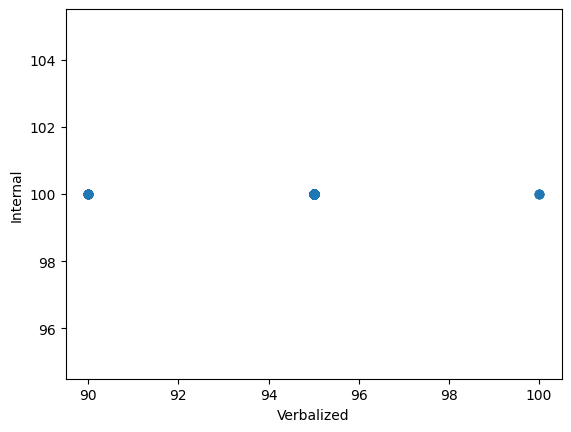

In [ ]:
# Связь между вербализованной и внутренней увереностью

plt.scatter(c_data["verb_confidence"], c_data["int_confidence"], alpha=0.3)
plt.xlabel("Verbalized")
plt.ylabel("Internal")
plt.show()

<Axes: ylabel='Frequency'>

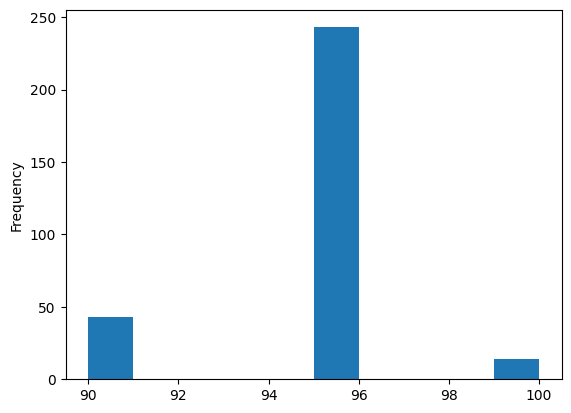

In [ ]:
# Вербализованная уверенность
c_data["verb_confidence"].plot(kind='hist')

<Axes: ylabel='Frequency'>

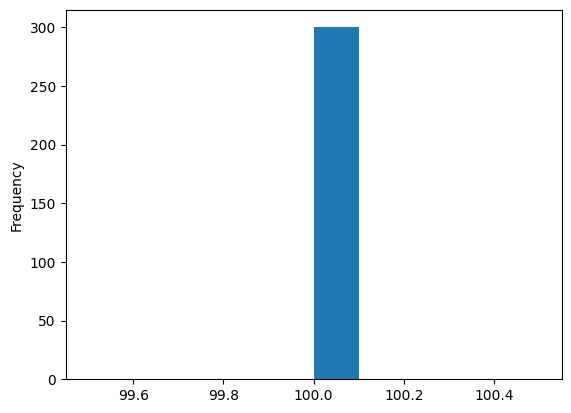

In [ ]:
# Внутренняя уверенность (константа)
c_data["int_confidence"].plot(kind='hist')